# [16.2] KernelSHAP and PartitionSHAP Controls - Solutions

## Core Question

When exact Shapley is known, which sampling and partition choices preserve the attribution, and which produce a confident but wrong answer?

**Claim:** on the six-player ground-truth game below, full-table KernelSHAP recovers exact Shapley; paired-kernel sampling has lower mean error than uniform sampling at the same partial budgets; and exact Owen values match Shapley for the declared interaction-aligned partition but shift by up to `0.300` for a fixed misaligned partition.

<img src="../../instructions/assets/kernelshap_partition_controls_signature.png" width="980">

```python
EXERCISE_ID = "16_2_kernelshap_and_partitionshap_controls"
GT_TIER = "GT-0"
DIFFICULTY = 4
IMPORTANCE = 4
EXPECTED_RUNTIME = "seconds on toy contract; minutes on local real-model path"
REQUIRES_GPU = True
```

## Learning Objectives

You will:

- build a finite interaction game with an independent exact oracle;
- implement the KernelSHAP kernel and constrained weighted regression;
- compare full-table and sampled KernelSHAP;
- implement uniform and complement-paired kernel sampling;
- validate player partitions and collapse group coalitions correctly;
- implement exact Owen values for a declared partition;
- test aligned, singleton, misaligned, and random partition controls.

The visible results are generated in this notebook from the implemented methods. No verification report is used as teaching evidence.


In [1]:
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass
import itertools
import math
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import torch as t

chapter = "chapter16_shapley_attribution_baselines"
section = "part2_kernelshap_partition_shap_controls"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
assets_dir = root_dir / chapter / "instructions" / "assets"
for path in (root_dir, exercises_dir):
    if str(path) not in sys.path:
        sys.path.append(str(path))

import part2_kernelshap_partition_shap_controls.tests as tests

Coalition = frozenset[int]
t.set_grad_enabled(False)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 10,
})
EXACT = "#B43A32"
PAIRED = "#167D8D"
UNIFORM = "#D39A2C"
CONTROL = "#5F6875"


@dataclass(frozen=True)
class KernelSHAPApproximationReport:
    shapley_values: t.Tensor
    exact_values: t.Tensor
    max_abs_error: float
    approximates_exact: bool


@dataclass(frozen=True)
class PartitionSHAPReport:
    group_values: t.Tensor
    player_values: t.Tensor
    exact_values: t.Tensor
    max_abs_error: float
    recovers_exact: bool


## Cold open: two approximations, two hidden choices

KernelSHAP replaces an exponential sum with weighted regression over sampled coalitions. PartitionSHAP restricts player orderings using a hierarchy or declared grouping. Both can return efficient-looking vectors even when sampling or grouping changed the answer.

This notebook fixes an exact target first. Six players have direct dividends, and two known three-way interactions connect `(0, 1, 2)` and `(3, 4, 5)`. The exact Shapley vector is `[1.2, 0.4, 1.1, -0.2, 0.1, -0.4]`.

<details><summary>Interpretation - what counts as failure?</summary>

An approximation fails when its maximum player error is large relative to the exact oracle, even if its values sum to the correct total. A partition result can satisfy efficiency while allocating interaction credit differently.

</details>


In [2]:
def all_coalitions(num_players: int) -> tuple[Coalition, ...]:
    if num_players <= 0:
        raise ValueError("num_players must be positive.")
    return tuple(
        frozenset(group)
        for size in range(num_players + 1)
        for group in itertools.combinations(range(num_players), size)
    )


def normalize_coalition_values(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    num_players: int,
) -> dict[Coalition, float]:
    normalized = {
        frozenset(key): float(value) for key, value in coalition_values.items()
    }
    expected = set(all_coalitions(num_players))
    missing = expected - set(normalized)
    extra = set(normalized) - expected
    if missing or extra:
        raise ValueError(
            f"coalition table has missing={len(missing)} and extra={len(extra)} coalitions"
        )
    return {coalition: normalized[coalition] for coalition in all_coalitions(num_players)}


def coalition_values_from_function(
    num_players: int,
    value_fn: Callable[[Coalition], float],
) -> dict[Coalition, float]:
    return {
        coalition: float(value_fn(coalition))
        for coalition in all_coalitions(num_players)
    }


def exact_shapley_values(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    num_players: int,
) -> t.Tensor:
    values = normalize_coalition_values(
        coalition_values, num_players=num_players
    )
    result = t.zeros(num_players, dtype=t.float64)
    denominator = math.factorial(num_players)
    for player in range(num_players):
        for coalition in all_coalitions(num_players):
            if player in coalition:
                continue
            size = len(coalition)
            weight = (
                math.factorial(size)
                * math.factorial(num_players - size - 1)
                / denominator
            )
            result[player] += weight * (
                values[coalition | {player}] - values[coalition]
            )
    return result


def additive_game(weights: t.Tensor) -> dict[Coalition, float]:
    weights = weights.detach().flatten().double()
    return coalition_values_from_function(
        int(weights.numel()),
        lambda coalition: weights[list(coalition)].sum().item()
        if coalition else 0.0,
    )


def conjunction_game(num_players: int) -> dict[Coalition, float]:
    full = frozenset(range(num_players))
    return coalition_values_from_function(
        num_players, lambda coalition: coalition == full
    )


### Exercise 1 - build the exact ground-truth game

Implement a game from Harsanyi dividends and an independent oracle that splits each dividend equally among its members. The baseline is zero, so every unit of full-game value belongs to at least one player.

<details><summary>Help - common bug</summary>

Coalition `S` receives dividend `d(T)` exactly when `T` is a subset of `S`. For the oracle, each player in `T` receives `d(T) / len(T)`.

</details>

<details><summary>Solution</summary>

```python
def game_from_dividends(num_players, dividends):
    normalized = {frozenset(term): float(value) for term, value in dividends.items()}
    return coalition_values_from_function(
        num_players,
        lambda coalition: sum(value for term, value in normalized.items() if term <= coalition),
    )

def shapley_from_dividends(num_players, dividends):
    result = t.zeros(num_players, dtype=t.float64)
    for term, value in dividends.items():
        for player in term:
            result[player] += value / len(term)
    return result
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_exact_dividend_game_oracle` passed!
Exact oracle = [1.200, 0.400, 1.100, -0.200, 0.100, -0.400]
Full-game value = 2.200; oracle parity error < 1e-12
```

</details>

<details><summary>Interpretation</summary>

The oracle does not use KernelSHAP or partition orderings. It is the fixed target against which both methods will be tested.

</details>


In [3]:
PLAYER_NAMES = ("embed", "attend", "mlp", "router", "memory", "readout")
GAME_DIVIDENDS = {
    frozenset({0}): 0.6,
    frozenset({1}): -0.2,
    frozenset({2}): 0.5,
    frozenset({3}): 0.1,
    frozenset({4}): 0.4,
    frozenset({5}): -0.1,
    frozenset({0, 1, 2}): 1.8,
    frozenset({3, 4, 5}): -0.9,
}
def game_from_dividends(
    num_players: int,
    dividends: Mapping[Coalition | tuple[int, ...], float],
) -> dict[Coalition, float]:
    normalized = {
        frozenset(term): float(value) for term, value in dividends.items()
    }
    if any(not term for term in normalized):
        raise ValueError("The empty dividend is a baseline, not player credit.")
    if any(player < 0 or player >= num_players for term in normalized for player in term):
        raise ValueError("Dividend contains an invalid player.")
    return coalition_values_from_function(
        num_players,
        lambda coalition: sum(
            value for term, value in normalized.items()
            if term.issubset(coalition)
        ),
    )


def shapley_from_dividends(
    num_players: int,
    dividends: Mapping[Coalition | tuple[int, ...], float],
) -> t.Tensor:
    result = t.zeros(num_players, dtype=t.float64)
    for raw_term, raw_value in dividends.items():
        term = frozenset(raw_term)
        if not term:
            raise ValueError("The empty dividend is a baseline, not player credit.")
        for player in term:
            result[player] += float(raw_value) / len(term)
    return result
tests.test_exact_dividend_game_oracle(
    game_from_dividends,
    shapley_from_dividends,
)
game_values = game_from_dividends(6, GAME_DIVIDENDS)
exact_oracle = shapley_from_dividends(6, GAME_DIVIDENDS)
exact_formula = exact_shapley_values(game_values, num_players=6)
oracle_parity_error = (exact_formula - exact_oracle).abs().max().item()
print("Exact oracle =", [round(value, 3) for value in exact_oracle.tolist()])
print(
    f"Full-game value = {game_values[frozenset(range(6))]:.3f}; "
    f"oracle parity error = {oracle_parity_error:.2e}"
)


All tests in `test_exact_dividend_game_oracle` passed!
Exact oracle = [1.2, 0.4, 1.1, -0.2, 0.1, -0.4]
Full-game value = 2.200; oracle parity error = 2.22e-16


### Exercise 2 - construct KernelSHAP regression rows

Implement the finite Shapley kernel

$$\pi(S)=\frac{{n-1}}{{\binom{{n}}{{|S|}}|S|(n-|S|)}}$$

for non-empty, non-full coalitions. Then construct the binary mask matrix `X`, baseline-centered target `y`, and row weights `w`.

<details><summary>Help - common bug</summary>

Reject the empty and full coalitions in the finite kernel. They are enforced separately by the baseline and efficiency constraint. Every row of `X` contains one for present players and zero otherwise.

</details>

<details><summary>Solution</summary>

```python
def kernelshap_kernel_weight(coalition_size, num_players):
    if not 0 < coalition_size < num_players:
        raise ValueError("Need 0 < coalition_size < num_players.")
    return (num_players - 1) / (math.comb(num_players, coalition_size) * coalition_size * (num_players - coalition_size))

def kernelshap_regression_rows(values, *, num_players, coalitions=None):
    values = normalize_coalition_values(values, num_players=num_players)
    rows = tuple(coalitions) if coalitions is not None else tuple(S for S in all_coalitions(num_players) if 0 < len(S) < num_players)
    X = t.tensor([[float(i in S) for i in range(num_players)] for S in rows], dtype=t.float64)
    y = t.tensor([values[S] - values[frozenset()] for S in rows], dtype=t.float64)
    w = t.tensor([kernelshap_kernel_weight(len(S), num_players) for S in rows], dtype=t.float64)
    return X, y, w
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_kernelshap_kernel_weight_uses_finite_coalition_formula` passed!
Kernel regression rows: X=(62, 6), y=(62,), w=(62,)
Singleton weight > size-3 weight; no empty/full finite rows
```

</details>

<details><summary>Interpretation</summary>

The kernel upweights extreme coalition sizes because they constrain individual marginal effects. Uniform row weighting solves a different regression problem.

</details>


In [4]:
def kernelshap_kernel_weight(coalition_size: int, num_players: int) -> float:
    if not 0 < coalition_size < num_players:
        raise ValueError("Need 0 < coalition_size < num_players.")
    return (num_players - 1) / (
        math.comb(num_players, coalition_size)
        * coalition_size
        * (num_players - coalition_size)
    )


def kernelshap_regression_rows(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    num_players: int,
    coalitions: Sequence[Coalition] | None = None,
) -> tuple[t.Tensor, t.Tensor, t.Tensor]:
    values = normalize_coalition_values(
        coalition_values, num_players=num_players
    )
    rows = (
        tuple(frozenset(coalition) for coalition in coalitions)
        if coalitions is not None
        else tuple(
            coalition for coalition in all_coalitions(num_players)
            if 0 < len(coalition) < num_players
        )
    )
    if not rows or any(len(coalition) in (0, num_players) for coalition in rows):
        raise ValueError("Regression rows must be non-empty interior coalitions.")
    X = t.tensor(
        [
            [float(player in coalition) for player in range(num_players)]
            for coalition in rows
        ],
        dtype=t.float64,
    )
    y = t.tensor(
        [values[coalition] - values[frozenset()] for coalition in rows],
        dtype=t.float64,
    )
    weights = t.tensor(
        [
            kernelshap_kernel_weight(len(coalition), num_players)
            for coalition in rows
        ],
        dtype=t.float64,
    )
    return X, y, weights
tests.test_kernelshap_kernel_weight_uses_finite_coalition_formula(
    kernelshap_kernel_weight
)
full_X, full_y, full_weights = kernelshap_regression_rows(
    game_values, num_players=6
)
assert full_X.shape == (62, 6)
assert kernelshap_kernel_weight(1, 6) > kernelshap_kernel_weight(3, 6)
print(
    f"Kernel regression rows: X={tuple(full_X.shape)}, "
    f"y={tuple(full_y.shape)}, w={tuple(full_weights.shape)}"
)
print("Kernel design-row tests passed!")


All tests in `test_kernelshap_kernel_weight_uses_finite_coalition_formula` passed!
Kernel regression rows: X=(62, 6), y=(62,), w=(62,)
Kernel design-row tests passed!


### Exercise 3 - solve constrained KernelSHAP

Solve weighted least squares with the hard efficiency constraint `sum(phi) = v(full) - v(empty)`. Use a direct KKT solve for the complete interior table. Partial coalition designs can be rank deficient, so define their estimator as the minimum-norm KKT least-squares solution.

<details><summary>Help - common bug</summary>

Form `X.T @ W @ X` and `X.T @ W @ y`. Add one row and column of ones to impose efficiency, and add the full-minus-empty delta to the right-hand side.

</details>

<details><summary>Solution</summary>

```python
def kernelshap_values(values, *, num_players, coalitions=None):
    X, y, w = kernelshap_regression_rows(values, num_players=num_players, coalitions=coalitions)
    gram = X.T @ (w[:, None] * X)
    rhs = X.T @ (w * y)
    kkt = t.zeros((num_players + 1, num_players + 1), dtype=t.float64)
    kkt[:num_players, :num_players] = gram
    kkt[:num_players, -1] = 1
    kkt[-1, :num_players] = 1
    delta = values[frozenset(range(num_players))] - values[frozenset()]
    constrained_rhs = t.cat([rhs, t.tensor([delta])])
    if X.shape[0] == 2**num_players - 2:
        return t.linalg.solve(kkt, constrained_rhs)[:num_players]
    return t.linalg.lstsq(kkt, constrained_rhs).solution[:num_players]
```

</details>

<details><summary>Expected output</summary>

```text
All additive and conjunction KernelSHAP tests passed!
Full-table KernelSHAP max error: < 1e-12
Efficiency error: < 1e-12
```

</details>

<details><summary>Interpretation</summary>

Full-table KernelSHAP is a parity check, not an approximation win: it has used all 62 interior coalitions. Sampling is where uncertainty enters.

</details>


In [5]:
def kernelshap_values(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    num_players: int,
    coalitions: Sequence[Coalition] | None = None,
) -> t.Tensor:
    values = normalize_coalition_values(
        coalition_values, num_players=num_players
    )
    X, y, weights = kernelshap_regression_rows(
        values,
        num_players=num_players,
        coalitions=coalitions,
    )
    gram = X.T @ (weights[:, None] * X)
    rhs = X.T @ (weights * y)
    kkt = t.zeros(
        (num_players + 1, num_players + 1), dtype=t.float64
    )
    kkt[:num_players, :num_players] = gram
    kkt[:num_players, -1] = 1.0
    kkt[-1, :num_players] = 1.0
    delta = (
        values[frozenset(range(num_players))]
        - values[frozenset()]
    )
    constrained_rhs = t.cat(
        [rhs, t.tensor([delta], dtype=t.float64)]
    )
    if X.shape[0] == 2**num_players - 2:
        return t.linalg.solve(kkt, constrained_rhs)[:num_players]
    return t.linalg.lstsq(kkt, constrained_rhs).solution[:num_players]


def kernelshap_approximation_report(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    num_players: int,
    tolerance: float = 1e-9,
) -> KernelSHAPApproximationReport:
    estimate = kernelshap_values(
        coalition_values, num_players=num_players
    )
    exact = exact_shapley_values(
        coalition_values, num_players=num_players
    )
    error = float((estimate - exact).abs().max().item())
    return KernelSHAPApproximationReport(
        shapley_values=estimate,
        exact_values=exact,
        max_abs_error=error,
        approximates_exact=error <= tolerance,
    )
tests.test_kernelshap_approximation_report_matches_exact_additive_game(
    kernelshap_approximation_report,
    additive_game,
)
tests.test_kernelshap_interaction_report_splits_conjunction_credit(
    kernelshap_approximation_report,
    conjunction_game,
)
full_kernel = kernelshap_values(game_values, num_players=6)
full_kernel_error = (full_kernel - exact_oracle).abs().max().item()
full_kernel_efficiency_error = abs(
    full_kernel.sum().item() - game_values[frozenset(range(6))]
)
print(f"Full-table KernelSHAP max error: {full_kernel_error:.2e}")
print(f"Efficiency error: {full_kernel_efficiency_error:.2e}")


All tests in `test_kernelshap_approximation_report_matches_exact_additive_game` passed!
All tests in `test_kernelshap_interaction_report_splits_conjunction_credit` passed!
Full-table KernelSHAP max error: 5.55e-16
Efficiency error: 0.00e+00


### Exercise 4 - sample coalitions with controls

Implement two sampling strategies without replacement. `uniform` samples interior coalitions uniformly. `paired_kernel` samples complement pairs with probability proportional to the Shapley kernel, so every selected `S` is accompanied by `N minus S`.

<details><summary>Help - common bug</summary>

Build the 31 unique complement pairs by tracking a `seen` set. Use a seeded `torch.Generator` and `torch.multinomial` for weighted pair selection. Return all 62 interior coalitions when the budget reaches 62.

</details>

<details><summary>Solution</summary>

```python
def sample_interior_coalitions(num_players, *, budget, seed, strategy):
    interior = [S for S in all_coalitions(num_players) if 0 < len(S) < num_players]
    if budget >= len(interior):
        return tuple(interior)
    generator = t.Generator().manual_seed(seed)
    if strategy == "uniform":
        indices = t.randperm(len(interior), generator=generator)[:budget]
        return tuple(interior[index] for index in indices.tolist())
    full, seen, pairs = frozenset(range(num_players)), set(), []
    for coalition in interior:
        if coalition in seen:
            continue
        complement = full - coalition
        pairs.append((coalition, complement))
        seen.update((coalition, complement))
    weights = t.tensor([kernelshap_kernel_weight(len(pair[0]), num_players) for pair in pairs], dtype=t.float64)
    pair_ids = t.multinomial(weights, budget // 2, replacement=False, generator=generator)
    return tuple(coalition for index in pair_ids.tolist() for coalition in pairs[index])
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_coalition_sampler_controls` passed!
All tests in `test_sampled_kernelshap_convergence_control` passed!
At budget 24, paired-kernel mean error < uniform mean error across fixed seeds
```

</details>

<details><summary>Interpretation</summary>

Complement pairing and kernel weighting reduce error on average for this game. They do not guarantee that every seed beats uniform sampling, and the comparison must use equal coalition budgets.

</details>


In [6]:
def sample_interior_coalitions(
    num_players: int,
    *,
    budget: int,
    seed: int,
    strategy: Literal["paired_kernel", "uniform"],
) -> tuple[Coalition, ...]:
    interior = [
        coalition for coalition in all_coalitions(num_players)
        if 0 < len(coalition) < num_players
    ]
    if budget <= 0:
        raise ValueError("budget must be positive.")
    if budget >= len(interior):
        return tuple(interior)
    generator = t.Generator().manual_seed(seed)
    if strategy == "uniform":
        indices = t.randperm(
            len(interior), generator=generator
        )[:budget]
        return tuple(interior[index] for index in indices.tolist())
    if strategy != "paired_kernel":
        raise ValueError("strategy must be 'paired_kernel' or 'uniform'.")
    if budget % 2:
        raise ValueError("paired_kernel requires an even budget.")

    full = frozenset(range(num_players))
    seen: set[Coalition] = set()
    pairs = []
    for coalition in interior:
        if coalition in seen:
            continue
        complement = full - coalition
        pairs.append((coalition, complement))
        seen.update((coalition, complement))
    pair_weights = t.tensor(
        [
            kernelshap_kernel_weight(len(pair[0]), num_players)
            for pair in pairs
        ],
        dtype=t.float64,
    )
    pair_ids = t.multinomial(
        pair_weights,
        budget // 2,
        replacement=False,
        generator=generator,
    )
    return tuple(
        coalition
        for index in pair_ids.tolist()
        for coalition in pairs[index]
    )
tests.test_coalition_sampler_controls(sample_interior_coalitions)
tests.test_sampled_kernelshap_convergence_control(
    game_from_dividends,
    shapley_from_dividends,
    sample_interior_coalitions,
    kernelshap_values,
)


All tests in `test_coalition_sampler_controls` passed!
All tests in `test_sampled_kernelshap_convergence_control` passed!


### Exercise 5 - validate and collapse a partition

A partition must cover every player exactly once. Implement validation, then map group coalitions back to their underlying player coalitions before looking up game values.

<details><summary>Help - common bug</summary>

Flatten all groups and compare the sorted players with `range(num_players)`. For group coalition `{1}`, union all players in `groups[1]`.

</details>

<details><summary>Solution</summary>

```python
def validate_partition(groups, num_players):
    players = [player for group in groups for player in group]
    if not groups or any(not group for group in groups) or sorted(players) != list(range(num_players)) or len(players) != len(set(players)):
        raise ValueError("partition players must cover each player exactly once")

def grouped_coalition_values(values, *, groups):
    num_players = len({player for group in groups for player in group})
    validate_partition(groups, num_players)
    values = normalize_coalition_values(values, num_players=num_players)
    return coalition_values_from_function(
        len(groups),
        lambda group_coalition: values[frozenset(player for index in group_coalition for player in groups[index])],
    )
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_grouped_coalition_values_expand_groups_before_lookup` passed!
Invalid overlapping and incomplete partitions are rejected
```

</details>

<details><summary>Interpretation</summary>

A group index is not a player index. Mixing these spaces can produce plausible totals while assigning credit to the wrong original variables.

</details>


In [7]:
def validate_partition(
    groups: tuple[tuple[int, ...], ...],
    num_players: int,
) -> None:
    players = [player for group in groups for player in group]
    if (
        not groups
        or any(not group for group in groups)
        or sorted(players) != list(range(num_players))
        or len(players) != len(set(players))
    ):
        raise ValueError(
            "partition players must cover each player exactly once"
        )


def grouped_coalition_values(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    groups: tuple[tuple[int, ...], ...],
) -> dict[Coalition, float]:
    num_players = len(
        {player for group in groups for player in group}
    )
    validate_partition(groups, num_players)
    values = normalize_coalition_values(
        coalition_values, num_players=num_players
    )
    return coalition_values_from_function(
        len(groups),
        lambda group_coalition: values[
            frozenset(
                player
                for group_index in group_coalition
                for player in groups[group_index]
            )
        ],
    )
tests.test_grouped_coalition_values_expand_groups_before_lookup(
    grouped_coalition_values,
    additive_game,
)
for invalid_groups in (((0, 1), (1, 2)), ((0, 1),)):
    try:
        validate_partition(invalid_groups, 3)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid partition should fail.")
print("Partition validation tests passed!")


All tests in `test_grouped_coalition_values_expand_groups_before_lookup` passed!
Partition validation tests passed!


### Exercise 6 - implement exact Owen values

For each player, average over which groups precede its group and which players precede it inside that group. This is the exact Owen-value calculation for a fixed partition, the cooperative-game object underlying the partition control in this lesson.

<details><summary>Help - common bug</summary>

Use a Shapley subset weight twice: once among groups and once within the player's group. The predecessor coalition is the union of every player in preceding groups plus preceding players in the current group.

</details>

<details><summary>Solution</summary>

```python
def partition_shap_values(values, *, groups):
    num_players = sum(len(group) for group in groups)
    validate_partition(groups, num_players)
    values = normalize_coalition_values(values, num_players=num_players)
    result = t.zeros(num_players, dtype=t.float64)
    for group_index, group in enumerate(groups):
        other_groups = [index for index in range(len(groups)) if index != group_index]
        for player in group:
            inside = [item for item in group if item != player]
            for outside_size in range(len(groups)):
                outside_weight = math.factorial(outside_size) * math.factorial(len(groups)-outside_size-1) / math.factorial(len(groups))
                for outside_indices in itertools.combinations(other_groups, outside_size):
                    outside = set().union(*(set(groups[index]) for index in outside_indices)) if outside_indices else set()
                    for inside_size in range(len(group)):
                        inside_weight = math.factorial(inside_size) * math.factorial(len(group)-inside_size-1) / math.factorial(len(group))
                        for inside_players in itertools.combinations(inside, inside_size):
                            before = frozenset(outside | set(inside_players))
                            result[player] += outside_weight * inside_weight * (values[before | {player}] - values[before])
    return result
```

</details>

<details><summary>Expected output</summary>

```text
Additive, symmetric-interaction, invalid-group, and cross-group tests all pass
Singleton groups reduce to ordinary exact Shapley
```

</details>

<details><summary>Interpretation</summary>

Owen values are exact for the game with a priori unions. They need not equal ordinary Shapley because the partition changes which predecessor orderings are allowed.

</details>


In [8]:
def partition_shap_values(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    groups: tuple[tuple[int, ...], ...],
) -> t.Tensor:
    num_players = sum(len(group) for group in groups)
    validate_partition(groups, num_players)
    values = normalize_coalition_values(
        coalition_values, num_players=num_players
    )
    result = t.zeros(num_players, dtype=t.float64)
    num_groups = len(groups)
    for group_index, group in enumerate(groups):
        other_groups = [
            index for index in range(num_groups)
            if index != group_index
        ]
        for player in group:
            inside_players = [item for item in group if item != player]
            for outside_size in range(num_groups):
                outside_weight = (
                    math.factorial(outside_size)
                    * math.factorial(num_groups - outside_size - 1)
                    / math.factorial(num_groups)
                )
                for outside_indices in itertools.combinations(
                    other_groups, outside_size
                ):
                    outside = (
                        set().union(
                            *(set(groups[index]) for index in outside_indices)
                        )
                        if outside_indices else set()
                    )
                    for inside_size in range(len(group)):
                        inside_weight = (
                            math.factorial(inside_size)
                            * math.factorial(len(group) - inside_size - 1)
                            / math.factorial(len(group))
                        )
                        for inside_before in itertools.combinations(
                            inside_players, inside_size
                        ):
                            before = frozenset(
                                outside | set(inside_before)
                            )
                            result[player] += (
                                outside_weight
                                * inside_weight
                                * (
                                    values[before | {player}]
                                    - values[before]
                                )
                            )
    return result


def partition_shap_report(
    coalition_values: Mapping[Coalition | tuple[int, ...], float],
    *,
    groups: tuple[tuple[int, ...], ...],
    tolerance: float = 1e-9,
) -> PartitionSHAPReport:
    num_players = sum(len(group) for group in groups)
    player_values = partition_shap_values(
        coalition_values, groups=groups
    )
    group_values = exact_shapley_values(
        grouped_coalition_values(coalition_values, groups=groups),
        num_players=len(groups),
    )
    exact_values = exact_shapley_values(
        coalition_values, num_players=num_players
    )
    error = float(
        (player_values - exact_values).abs().max().item()
    )
    return PartitionSHAPReport(
        group_values=group_values,
        player_values=player_values,
        exact_values=exact_values,
        max_abs_error=error,
        recovers_exact=error <= tolerance,
    )
tests.test_partition_shap_report_recovers_additive_groups(
    partition_shap_report,
    additive_game,
)
tests.test_partition_shap_report_rejects_invalid_grouping(
    partition_shap_report,
    additive_game,
)
tests.test_partition_shap_report_splits_interaction_group_symmetrically(
    partition_shap_report,
    conjunction_game,
)
tests.test_partition_shap_report_handles_cross_group_interaction_without_irrelevant_credit(
    partition_shap_report,
    coalition_values_from_function,
)
singleton_partition = tuple((player,) for player in range(6))
singleton_values = partition_shap_values(
    game_values, groups=singleton_partition
)
t.testing.assert_close(singleton_values, exact_oracle, atol=1e-12, rtol=0)
print("PartitionSHAP semantic tests passed!")


All tests in `test_partition_shap_report_recovers_additive_groups` passed!
All tests in `test_partition_shap_report_rejects_invalid_grouping` passed!
All tests in `test_partition_shap_report_splits_interaction_group_symmetrically` passed!
All tests in `test_partition_shap_report_handles_cross_group_interaction_without_irrelevant_credit` passed!
PartitionSHAP semantic tests passed!


### Exercise 7 - test aligned and random partitions

The declared interactions are entirely inside `((0, 1, 2), (3, 4, 5))`, so that aligned partition matches ordinary Shapley. Test it against the fixed misaligned partition `((0, 3, 4), (1, 2, 5))`, then sample 100 seeded balanced partitions.

<details><summary>Help - common bug</summary>

Generate a seeded random permutation of six players and use the first three and last three as groups. Measure each partition by maximum absolute error from the exact oracle. Preserve every sampled result, including repeated partitions, because the seeds are the experimental units.

</details>

<details><summary>Solution</summary>

```python
aligned_groups = ((0, 1, 2), (3, 4, 5))
misaligned_groups = ((0, 3, 4), (1, 2, 5))
aligned = partition_shap_values(game_values, groups=aligned_groups)
misaligned = partition_shap_values(game_values, groups=misaligned_groups)
random_errors = []
for seed in range(100):
    ordering = t.randperm(6, generator=t.Generator().manual_seed(seed)).tolist()
    groups = (tuple(sorted(ordering[:3])), tuple(sorted(ordering[3:])))
    random_errors.append((partition_shap_values(game_values, groups=groups) - exact_oracle).abs().max().item())
```

</details>

<details><summary>Expected output</summary>

```text
All tests in `test_partition_alignment_and_random_control` passed!
Aligned error = 0.000; fixed misaligned error = 0.300
91 / 100 seeded random balanced partitions differ from exact Shapley
```

</details>

<details><summary>Interpretation</summary>

Efficiency alone cannot detect the misaligned result: both vectors sum to `2.2`. The error comes from changing the allowed orderings, which redistributes each three-way dividend according to how its members are split across groups.

</details>


In [9]:
tests.test_partition_alignment_and_random_control(
    game_from_dividends,
    shapley_from_dividends,
    partition_shap_values,
)
aligned_groups = ((0, 1, 2), (3, 4, 5))
misaligned_groups = ((0, 3, 4), (1, 2, 5))
aligned_values = partition_shap_values(game_values, groups=aligned_groups)
misaligned_values = partition_shap_values(game_values, groups=misaligned_groups)
aligned_error = (aligned_values - exact_oracle).abs().max().item()
misaligned_error = (misaligned_values - exact_oracle).abs().max().item()

random_partition_errors = []
random_partitions = []
for seed in range(100):
    generator = t.Generator().manual_seed(seed)
    ordering = t.randperm(6, generator=generator).tolist()
    groups = (
        tuple(sorted(ordering[:3])),
        tuple(sorted(ordering[3:])),
    )
    values = partition_shap_values(game_values, groups=groups)
    random_partitions.append(groups)
    random_partition_errors.append(
        (values - exact_oracle).abs().max().item()
    )
nonexact_random_partitions = sum(
    error > 1e-9 for error in random_partition_errors
)
print(f"Aligned error = {aligned_error:.3f}")
print(f"Fixed misaligned error = {misaligned_error:.3f}")
print(
    f"{nonexact_random_partitions} / 100 seeded random balanced partitions "
    "differ from exact Shapley"
)


All tests in `test_partition_alignment_and_random_control` passed!


Aligned error = 0.000
Fixed misaligned error = 0.300
91 / 100 seeded random balanced partitions differ from exact Shapley


## Signature Result

Run 50 fixed seeds at six equal coalition budgets. Compare paired-kernel and uniform sampling, then preserve a randomized-value negative control that shuffles all interior coalition values while keeping the empty and full endpoints fixed.

The partition panels compare ordinary exact Shapley with aligned, singleton, misaligned, and random balanced partitions.


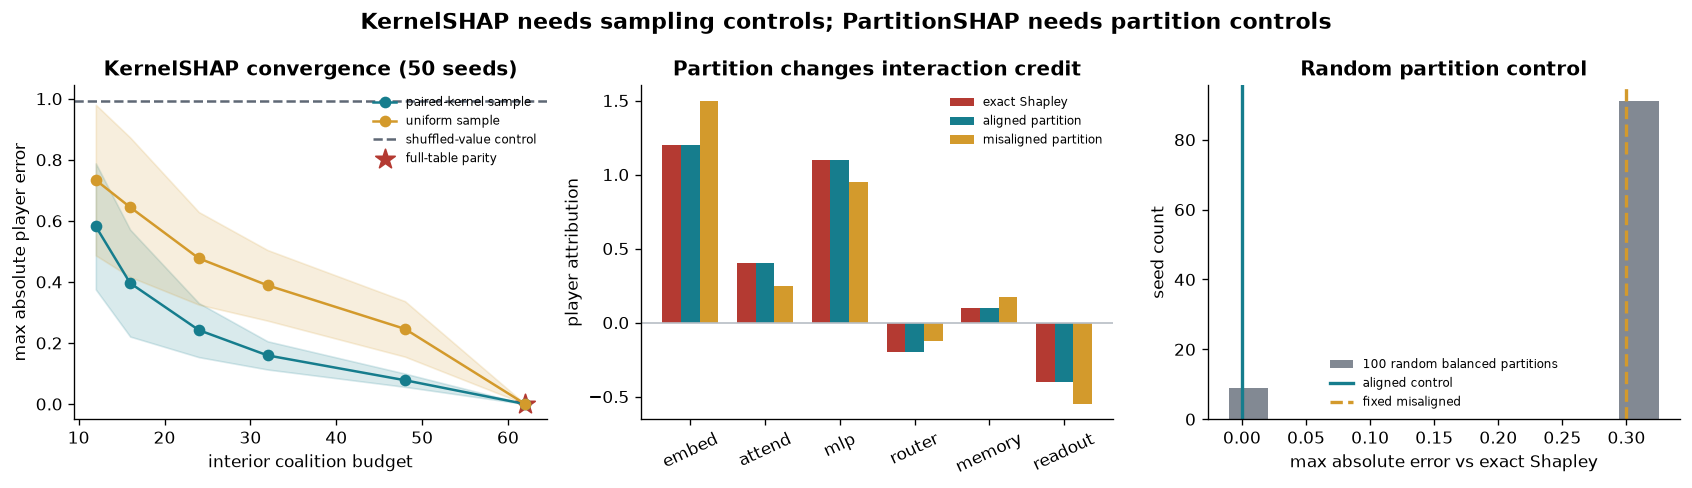

Signature metrics: full_error=5.55e-16, budget24_paired=0.242, budget24_uniform=0.477, shuffled_value_error=0.994, aligned_error=0.000, misaligned_error=0.300, random_nonexact=91/100


In [10]:
budgets = t.tensor([12, 16, 24, 32, 48, 62])
seeds = range(50)
sampling_errors = {}
for strategy in ("paired_kernel", "uniform"):
    matrix = t.zeros((len(budgets), len(tuple(seeds))), dtype=t.float64)
    for budget_index, budget in enumerate(budgets.tolist()):
        for seed in seeds:
            sample = sample_interior_coalitions(
                6,
                budget=budget,
                seed=seed,
                strategy=strategy,
            )
            estimate = kernelshap_values(
                game_values,
                num_players=6,
                coalitions=sample,
            )
            matrix[budget_index, seed] = (
                estimate - exact_oracle
            ).abs().max()
    sampling_errors[strategy] = matrix

interior = tuple(
    coalition for coalition in all_coalitions(6)
    if 0 < len(coalition) < 6
)
randomized_value_errors = []
for seed in seeds:
    generator = t.Generator().manual_seed(100 + seed)
    shuffled = dict(game_values)
    interior_values = t.tensor(
        [game_values[coalition] for coalition in interior],
        dtype=t.float64,
    )
    permutation = t.randperm(len(interior), generator=generator)
    for coalition, value in zip(interior, interior_values[permutation].tolist()):
        shuffled[coalition] = value
    randomized_estimate = kernelshap_values(
        shuffled, num_players=6
    )
    randomized_value_errors.append(
        (randomized_estimate - exact_oracle).abs().max().item()
    )

paired_mean = sampling_errors["paired_kernel"].mean(dim=1)
paired_std = sampling_errors["paired_kernel"].std(dim=1)
uniform_mean = sampling_errors["uniform"].mean(dim=1)
uniform_std = sampling_errors["uniform"].std(dim=1)
randomized_mean = float(np.mean(randomized_value_errors))

assert full_kernel_error < 1e-12
assert paired_mean[2] < uniform_mean[2]
assert aligned_error < 1e-12
assert abs(misaligned_error - 0.3) < 1e-12
assert randomized_mean > 0.5

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.1))
axes[0].plot(budgets, paired_mean, marker="o", color=PAIRED, label="paired-kernel sample")
axes[0].fill_between(budgets, paired_mean - paired_std, paired_mean + paired_std, color=PAIRED, alpha=0.16)
axes[0].plot(budgets, uniform_mean, marker="o", color=UNIFORM, label="uniform sample")
axes[0].fill_between(budgets, uniform_mean - uniform_std, uniform_mean + uniform_std, color=UNIFORM, alpha=0.16)
axes[0].axhline(randomized_mean, color=CONTROL, linestyle="--", label="shuffled-value control")
axes[0].scatter([62], [full_kernel_error], color=EXACT, marker="*", s=150, label="full-table parity")
axes[0].set_xlabel("interior coalition budget")
axes[0].set_ylabel("max absolute player error")
axes[0].set_title("KernelSHAP convergence (50 seeds)")
axes[0].legend(frameon=False, fontsize=7)

x = np.arange(6)
width = 0.25
axes[1].bar(x - width, exact_oracle, width, color=EXACT, label="exact Shapley")
axes[1].bar(x, aligned_values, width, color=PAIRED, label="aligned partition")
axes[1].bar(x + width, misaligned_values, width, color=UNIFORM, label="misaligned partition")
axes[1].axhline(0, color="#B8BDC5", linewidth=1)
axes[1].set_xticks(x, PLAYER_NAMES, rotation=25)
axes[1].set_ylabel("player attribution")
axes[1].set_title("Partition changes interaction credit")
axes[1].legend(frameon=False, fontsize=7)

bins = np.linspace(-0.01, 0.325, 12)
axes[2].hist(random_partition_errors, bins=bins, color=CONTROL, alpha=0.78, label="100 random balanced partitions")
axes[2].axvline(aligned_error, color=PAIRED, linewidth=2, label="aligned control")
axes[2].axvline(misaligned_error, color=UNIFORM, linestyle="--", linewidth=2, label="fixed misaligned")
axes[2].set_xlabel("max absolute error vs exact Shapley")
axes[2].set_ylabel("seed count")
axes[2].set_title("Random partition control")
axes[2].legend(frameon=False, fontsize=7)

fig.suptitle(
    "KernelSHAP needs sampling controls; PartitionSHAP needs partition controls",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
signature_path = assets_dir / "kernelshap_partition_controls_signature.png"
fig.savefig(signature_path, dpi=170, bbox_inches="tight")
plt.show()

print(
    f"Signature metrics: full_error={full_kernel_error:.2e}, "
    f"budget24_paired={paired_mean[2]:.3f}, "
    f"budget24_uniform={uniform_mean[2]:.3f}, "
    f"shuffled_value_error={randomized_mean:.3f}, "
    f"aligned_error={aligned_error:.3f}, "
    f"misaligned_error={misaligned_error:.3f}, "
    f"random_nonexact={nonexact_random_partitions}/100"
)


<details><summary>Interpreting the signature result</summary>

Paired-kernel sampling dominates uniform sampling on average at every partial budget in this organism, and both reach exact parity only at all 62 interior coalitions. Shuffling coalition values preserves the endpoints and therefore efficiency, but destroys the player attribution. The aligned and singleton partitions recover exact Shapley; the misaligned and most random partitions conserve total value while redistributing interaction credit.

</details>


### Try It Yourself - change budget, seed, and partition

Set the three parameters before inspecting the answer. Compare both samplers at the same budget, and always report the exact-oracle error alongside the attribution vector.


In [11]:
PLAY_BUDGET = 24
PLAY_SEED = 4
PLAY_STRATEGY: Literal["paired_kernel", "uniform"] = "paired_kernel"
PLAY_GROUPS = ((0, 3, 4), (1, 2, 5))

play_sample = sample_interior_coalitions(
    6,
    budget=PLAY_BUDGET,
    seed=PLAY_SEED,
    strategy=PLAY_STRATEGY,
)
play_kernel = kernelshap_values(
    game_values, num_players=6, coalitions=play_sample
)
play_partition = partition_shap_values(
    game_values, groups=PLAY_GROUPS
)
print(
    f"KernelSHAP ({PLAY_STRATEGY}, budget={PLAY_BUDGET}, seed={PLAY_SEED}):",
    [round(value, 3) for value in play_kernel.tolist()],
)
print(
    "Kernel max error:",
    round((play_kernel - exact_oracle).abs().max().item(), 3),
)
print("Partition:", PLAY_GROUPS)
print(
    "Partition values:",
    [round(value, 3) for value in play_partition.tolist()],
)
print(
    "Partition max error:",
    round((play_partition - exact_oracle).abs().max().item(), 3),
)


KernelSHAP (paired_kernel, budget=24, seed=4): [1.332, 0.522, 1.18, -0.322, -0.032, -0.479]
Kernel max error: 0.132
Partition: ((0, 3, 4), (1, 2, 5))
Partition values: [1.5, 0.25, 0.95, -0.125, 0.175, -0.55]
Partition max error: 0.3


## Bonus anomaly hunt

Find a seed at budget `24` where uniform sampling beats paired-kernel sampling, even though paired-kernel wins on average. Explain why one-seed screenshots are weak evidence. Then inspect the nine random-partition seeds that happen to recover exact Shapley: which partitions keep both three-way dividend sets intact?

For a harder anomaly, add a new dividend on `{0, 1, 3}`. Predict which previously aligned partition now changes credit before rerunning the controls.

## Real-method connection

`shap.KernelExplainer` uses the same weighted linear-regression view, but practical runs sample masks and depend on the masking/background definition. `shap.PartitionExplainer` restricts coalitions using a hierarchy and can compute Owen values. The exact finite game here isolates approximation and grouping error before those choices are mixed with model and masking behavior.

## Limitations

- The six-player game has 64 exact coalitions; real attribution problems rarely expose a complete, trustworthy table.
- The paired sampler is one transparent control, not a claim of optimal sampling for every game.
- The partition is supplied directly. A learned clustering can introduce additional estimation error.
- Owen values are correct for their restricted-ordering game even when they differ from ordinary Shapley.
- This notebook does not test token masking, background datasets, conditional expectations, or model-distribution shift.

## Reading links

- [A Unified Approach to Interpreting Model Predictions](https://arxiv.org/abs/1705.07874)
- [SHAP KernelExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html)
- [SHAP PartitionExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.PartitionExplainer.html)
- [Values of Games with A Priori Unions](https://doi.org/10.1007/BF01774766)
- [Section 16.1 exact-Shapley notebook](../part1_exact_shapley_ground_truth_games/16.1_Exact_Shapley_on_Ground_Truth_Games_exercises.ipynb)


## Verification Appendix

The exercises and signature result run on CPU. The full verification entry point trains and evaluates the finite neural coalition-game preflight on CUDA; `verification_report.json` is supporting regression evidence, not the lesson.


In [12]:
from part2_kernelshap_partition_shap_controls import solutions as reference

def run_smoke_test(cpu: bool = True) -> dict:
    return reference.run_smoke_test(cpu=cpu)

def run_gpu_test(max_vram_gb: float = 24.0) -> dict:
    return reference.run_gpu_test(max_vram_gb=max_vram_gb)

def run_full_experiment(max_vram_gb: float = 24.0) -> dict:
    return reference.run_full_experiment(max_vram_gb=max_vram_gb)

verification_summary = run_smoke_test(cpu=True)
verification_summary


{'kernel_additive': {'shapley_values': [1.0, -2.0, 0.5],
  'exact_values': [1.0, -2.0, 0.5],
  'max_abs_error': 0.0,
  'approximates_exact': True},
 'kernel_interaction': {'shapley_values': [0.3333333333333333,
   0.3333333333333333,
   0.33333333333333326],
  'exact_values': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333],
  'max_abs_error': 5.551115123125783e-17,
  'approximates_exact': True},
 'partition_additive': {'group_values': [3.0, 7.0],
  'player_values': [1.0, 2.0, 3.0, 4.0],
  'exact_values': [1.0, 2.0, 3.0, 4.0],
  'max_abs_error': 0.0,
  'recovers_exact': True},
 'partition_interaction': {'group_values': [1.0],
  'player_values': [0.5, 0.5],
  'exact_values': [0.5, 0.5],
  'max_abs_error': 0.0,
  'recovers_exact': True},
 'partition_cross_group_interaction': {'group_values': [0.5, 0.5],
  'player_values': [0.5, 0.0, 0.5],
  'exact_values': [0.5, 0.0, 0.5],
  'max_abs_error': 0.0,
  'recovers_exact': True}}